# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import pickle
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import sys
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from sklearn.metrics import ndcg_score
from collections import Counter
from catboost import CatBoostClassifier, Pool
import boto3
import io
import os
from dotenv import load_dotenv
from botocore.client import Config
import psutil
from botocore.exceptions import ClientError
load_dotenv(override=True)

pd.options.mode.chained_assignment = None

/Users/slavacalestru/Desktop/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def check_memory_imprint():
    memory = psutil.virtual_memory()

    print("Available RAM:", memory.available / (1024**3), "GB")
    print("Total RAM:", memory.total / (1024**3), "GB")
    print("Used RAM:", memory.used / (1024**3), "GB")
    print("RAM usage percent:", memory.percent, "%")

check_memory_imprint()

Available RAM: 4.1874542236328125 GB
Total RAM: 18.0 GB
Used RAM: 7.6917572021484375 GB
RAM usage percent: 76.7 %


In [3]:
# Вспомогательная функция для получения клиента s3
def get_s3_client():
    return boto3.client(
        "s3",
        aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
        aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
        endpoint_url="https://storage.yandexcloud.net",
        config=Config(
            signature_version="s3v4",
            s3={"payload_signing_enabled": False}
        )
    )


# Функция для провекри если файл есть в s3 бакете
def s3_exists(key):
    bucket = os.environ["S3_BUCKET_NAME"]
    s3 = get_s3_client()

    try:
        s3.head_object(Bucket=bucket, Key=key)
        return True
    except ClientError:
        return False


# Функции для сохранения и загрузки объектов в S3
def to_s3(obj, key):
    bucket = os.environ["S3_BUCKET_NAME"]
    s3 = get_s3_client()

    buf = io.BytesIO()

    if key.endswith(".parquet"):
        obj.to_parquet(buf, index=False)
    elif key.endswith(".pkl"):
        pickle.dump(obj, buf)
    else:
        raise ValueError(f"Неподдерживаемый формат: {key}")

    buf.seek(0)

    s3.put_object(
        Bucket=bucket,
        Key=key,
        Body=buf.getvalue()
    )

    print(f"Загружено в s3://{bucket}/{key}")


def from_s3(key):
    bucket = os.environ["S3_BUCKET_NAME"]
    s3 = get_s3_client()

    buf = io.BytesIO(
        s3.get_object(Bucket=bucket, Key=key)["Body"].read()
    )

    if key.endswith(".parquet"):
        print(f"loading from S3: {key}")
        return pd.read_parquet(buf)
    elif key.endswith(".pkl"):
        print(f"loading from S3: {key}")
        return pickle.load(buf)
    else:
        raise ValueError(f"Неподдерживаемый формат: {key}")




def clear_s3_bucket():
    bucket = os.environ["S3_BUCKET_NAME"]
    s3 = get_s3_client()

    paginator = s3.get_paginator("list_objects_v2")
    pages = paginator.paginate(Bucket=bucket)

    deleted_count = 0

    for page in pages:
        objects = page.get("Contents", [])
        if not objects:
            continue

        delete_payload = {"Objects": [{"Key": obj["Key"]} for obj in objects]}
        response = s3.delete_objects(Bucket=bucket, Delete=delete_payload)

        deleted_count += len(response.get("Deleted", []))

        errors = response.get("Errors", [])
        if errors:
            for err in errors:
                print(f"Ошибка при удалении {err['Key']}: {err['Code']} - {err['Message']}")

    print(f"Удалено объектов из s3://{bucket}: {deleted_count}")

In [4]:
clear_s3_bucket()

KeyError: 'S3_BUCKET_NAME'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [ ]:
# Загрузка данных из parquet файлов

df_tracks = pd.read_parquet("tracks.parquet")
df_catalog = pd.read_parquet("catalog_names.parquet")
df_interactions = pd.read_parquet("interactions.parquet", columns=["user_id", "track_id", "track_seq"])

to_s3(df_tracks, "tracks.parquet")
to_s3(df_catalog, "catalog_names.parquet")
to_s3(df_interactions, "interactions.parquet")

Загружено в s3://s3-student-mle-20260122-573229bfa1/tracks.parquet
Загружено в s3://s3-student-mle-20260122-573229bfa1/catalog_names.parquet
Загружено в s3://s3-student-mle-20260122-573229bfa1/interactions.parquet


In [ ]:
check_memory_imprint()

Available RAM: 22.505661010742188 GB
Total RAM: 31.340160369873047 GB
Used RAM: 8.83449935913086 GB
RAM usage percent: 28.2 %


In [ ]:
df_interactions["user_id"].nunique()

1373221

In [ ]:
# Данные о треках

df_tracks.head()

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


In [ ]:
# Каталог треков, альбомов, исполнителей и жанров

df_catalog.head()

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [ ]:
# Данные о взаимодействиях пользователей с треками

df_interactions.head()

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [ ]:
# Приводим типы данных к нужным для анализа и моделирования
df_tracks["track_id"] = df_tracks["track_id"].astype(int)
df_catalog["id"] = df_catalog["id"].astype(int)
df_interactions["user_id"] = df_interactions["user_id"].astype(int)
df_interactions["track_id"] = df_interactions["track_id"].astype(int)

# Проверяем изменения типов данных
print("Типы данных после изменения:")
print(df_tracks.dtypes)
print(df_catalog.dtypes)
print(df_interactions.dtypes)

# Разделяем каталог на отдельные датафреймы для треков, альбомов, исполнителей и жанров
df_tracks_info = df_catalog[df_catalog["type"] == "track"]
df_albums_info = df_catalog[df_catalog["type"] == "album"]
df_artists_info = df_catalog[df_catalog["type"] == "artist"]
df_genres_info = df_catalog[df_catalog["type"] == "genre"]

Типы данных после изменения:
track_id     int64
albums      object
artists     object
genres      object
dtype: object
id       int64
type    object
name    object
dtype: object
user_id                int64
track_id               int64
track_seq              int16
started_at    datetime64[ns]
dtype: object


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [ ]:
# Проверяем наличие пропущенных значений в каждом датафрейме

print("=== Пропущенные значения ===")
print("\ndf_tracks:")
print(df_tracks.isnull().sum())
print(f"Всего строк: {len(df_tracks)}")

print("\ndf_catalog:")
print(df_catalog.isnull().sum())
print(f"Всего строк: {len(df_catalog)}")

print("\ndf_interactions:")
print(df_interactions.isnull().sum())
print(f"Всего строк: {len(df_interactions)}")

=== Пропущенные значения ===

df_tracks:
track_id    0
albums      0
artists     0
genres      0
dtype: int64
Всего строк: 1000000

df_catalog:
id      0
type    0
name    0
dtype: int64
Всего строк: 1812471

df_interactions:


user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64
Всего строк: 222629898


In [ ]:
# # UNCOMMENT

# # Проверяем наличие дубликатов в каждом датафрейме
# print("=== Дубликаты ===")                                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                                
# print(f"\nДубликатов в df_tracks (по track_id): {df_tracks.duplicated(subset=['track_id']).sum()}")                                                                                                                                                            
                                                                                                                                                                                                                                                                
# print(f"\nДубликатов в df_catalog (по id и type): {df_catalog.duplicated(subset=['id', 'type']).sum()}")                                                                                                                                                       
# print(f"Полных дубликатов в df_catalog: {df_catalog.duplicated().sum()}")
                                                                                                                                                                                                                                                                
# print(f"\nДубликатов в df_interactions (по user_id и track_id): {(df_interactions.groupby(['user_id', 'track_id']).size() > 1).sum()}")      

In [ ]:
# Проверяем наличие пустых списков в метаданных треков
print("=== Пустые списки метаданных в df_tracks ===")
print(f"Нет информации об альбомах:  {df_tracks['albums'].apply(lambda x: len(x) == 0).sum()}")
print(f"Нет информации об исполнителях: {df_tracks['artists'].apply(lambda x: len(x) == 0).sum()}")
print(f"Нет информации о жанрах:  {df_tracks['genres'].apply(lambda x: len(x) == 0).sum()}")
print()

# Проверяем наличие треков в взаимодействиях, которых нет в df_tracks
interaction_tracks = set(df_interactions['track_id'])
known_tracks = set(df_tracks['track_id'])
missing_in_tracks = interaction_tracks - known_tracks
print(f"=== Проверяем если есть треки в взаимодействиях, которых нет в df_tracks ===")
print(f"Отсутствует: {len(missing_in_tracks)} из {len(interaction_tracks)} уникальных взаимодействий треков")
if missing_in_tracks:
    print(f"Примеры если есть: {list(missing_in_tracks)[:10]}")
print()

=== Пустые списки метаданных в df_tracks ===
Нет информации об альбомах:  18
Нет информации об исполнителях: 15369
Нет информации о жанрах:  3687

=== Проверяем если есть треки в взаимодействиях, которых нет в df_tracks ===
Отсутствует: 0 из 1000000 уникальных взаимодействий треков



In [ ]:
# Проверяем наличие треков с неизвестными альбомами, исполнителями и жанрами (те которые не представлены в каталоге)

# Создаем сеты известных ID альбомов, исполнителей и жанров из каталога
known_album_ids = set(df_albums_info["id"])
known_artist_ids = set(df_artists_info["id"])
known_genre_ids = set(df_genres_info["id"])

# Создаем сеты всех ID альбомов, исполнителей и жанров, которые встречаются в df_tracks
all_album_ids = set(id for ids in df_tracks["albums"] for id in ids)
all_artist_ids = set(id for ids in df_tracks["artists"] for id in ids)
all_genre_ids = set(id for ids in df_tracks["genres"] for id in ids)

# Вычисляем неизвестные ID, которые есть в df_tracks, но нет в каталоге
unknown_albums = all_album_ids - known_album_ids
unknown_artists = all_artist_ids - known_artist_ids
unknown_genres = all_genre_ids - known_genre_ids

# Выводим результаты проверки
print(f"Неизвестные альбомы: {len(unknown_albums)} из {len(all_album_ids)}")
print(f"Неизвестные исполнители: {len(unknown_artists)} из {len(all_artist_ids)}")
print(f"Неизвестные жанры: {len(unknown_genres)} из {len(all_genre_ids)}")

Неизвестные альбомы: 0 из 658724
Неизвестные исполнители: 0 из 153581
Неизвестные жанры: 30 из 173


In [ ]:
# Подсчитываем сколько треков имеют неизвестные альбомы, исполнителей или жанры

# Подсчитываем количество треков с неизвестными альбомами, исполнителями и жанрами
tracks_unknown_album = df_tracks["albums"].apply(lambda x: bool(set(x) & unknown_albums)).sum()
tracks_unknown_artist = df_tracks["artists"].apply(lambda x: bool(set(x) & unknown_artists)).sum()
tracks_unknown_genre = df_tracks["genres"].apply(lambda x: bool(set(x) & unknown_genres)).sum()

# Выводим результаты
print(f"Треков с неизвестными альбомами: {tracks_unknown_album}")
print(f"Треков с неизвестными исполнителями: {tracks_unknown_artist}")
print(f"Треков с неизвестными жанрами: {tracks_unknown_genre}")

# Создаем датафрейм с треками, которые имеют неизвестные альбомы, исполнителей или жанры
has_unknown_album = df_tracks["albums"].apply(lambda x: bool(set(x) - known_album_ids))                                                       
has_unknown_artist = df_tracks["artists"].apply(lambda x: bool(set(x) - known_artist_ids))                                                    
has_unknown_genre = df_tracks["genres"].apply(lambda x: bool(set(x) - known_genre_ids))

# Объединяем условия для треков с неизвестными данными
df_tracks_unknown = df_tracks[has_unknown_album | has_unknown_artist | has_unknown_genre]                                                     
print(f"Треков с неизвестными данными: {len(df_tracks_unknown)}")                                                                             

# Просматриваем примеры треков с неизвестными данными
df_tracks_unknown.head()

Треков с неизвестными альбомами: 0
Треков с неизвестными исполнителями: 0
Треков с неизвестными жанрами: 48345
Треков с неизвестными данными: 48345


,track_id,albums,artists,genres
36,436,[36],[330],"[28, 164]"
59,594,"[54, 88, 5479, 5785124, 9198099, 9231427, 1088...",[533],"[28, 162]"
125,1025,"[94, 2325, 8757, 8986, 318695, 17004129]",[937],"[28, 162]"
126,1026,"[94, 780, 8727]",[937],"[28, 162]"
128,1028,"[94, 4865, 19666753, 19666891]",[936],"[28, 162]"


In [ ]:
# Для треков с неизвестными данными, заменим неизвестные ID на специальный ID для "Unknown" и добавим его в каталог

# Создаем специальный ID для "Unknown"
DUMMY_UNKNOWN_ID = -1                                                                          

# Заменяем неизвестные ID жанров (те которые не представлены в каталоге) 
df_tracks["genres"] = df_tracks["genres"].apply(
    lambda x: [g if g in known_genre_ids else DUMMY_UNKNOWN_ID for g in x]                                                                    
)                                                                                                                                             
# Убираем дубликаты жанров после замены
df_tracks["genres"] = df_tracks["genres"].apply(lambda x: list(dict.fromkeys(x)))

# Заполняем пустые исполнители                                                                                                                                                                                                                                         
df_tracks["artists"] = df_tracks["artists"].apply(                                                                                                                                                                                                             
    lambda x: x if len(x) > 0 else [DUMMY_UNKNOWN_ID]                                                                                                                                                                                                         
)

# Заполняем пустые альбомы
df_tracks["albums"] = df_tracks["albums"].apply(
    lambda x: x if len(x) > 0 else [DUMMY_UNKNOWN_ID]                                                                                                                                                                                                          
)
                                                                                                                                                                                                                                                                
# Заполняем пустые жанры
df_tracks["genres"] = df_tracks["genres"].apply(
    lambda x: x if len(x) > 0 else [DUMMY_UNKNOWN_ID]
)

# Добавляем "Unknown" в каталог жанров
df_genres_info = pd.concat([                                                                                                                  
    df_genres_info,                                                                                                                           
    pd.DataFrame({"id": [DUMMY_UNKNOWN_ID], "type": ["genre"], "name": ["Unknown"]})
], ignore_index=True)

# Добавляем "Unknown" в каталог исполнителей и альбомов
df_artists_info = pd.concat([                                                                                                                                                                                                                                  
    df_artists_info,                                                                                                                                                                                                                                           
    pd.DataFrame({"id": [DUMMY_UNKNOWN_ID], "type": ["artist"], "name": ["Unknown"]})                                                                                                                                                                         
], ignore_index=True)                                                                                                                                                                                                                                          

# Добавляем "Unknown" в каталог альбомов
df_albums_info = pd.concat([                                                                                                                                                                                                                                   
    df_albums_info,                                                                                                                                                                                                                                            
    pd.DataFrame({"id": [DUMMY_UNKNOWN_ID], "type": ["album"], "name": ["Unknown"]})                                                                                                                                                                           
], ignore_index=True)   

# Подсчитываем сколько всего треков с Unknown жанром после замены (те которые были с неизвестными жанрами и те которые были с пустыми жанрами)
print(f"Треков с неизвестным жанром: {df_tracks['genres'].apply(lambda x: DUMMY_UNKNOWN_ID in x).sum()}")

# Проверяем что после замены неизвестных жанров на "Unknown" не осталось треков с неизвестными жанрами (те которые не представлены в каталоге)
known_genre_ids = set(df_genres_info["id"])
all_genre_ids = set(id for ids in df_tracks["genres"] for id in ids)
unknown_genres = all_genre_ids - known_genre_ids
print(f"Неизвестные жанры: {len(unknown_genres)} из {len(all_genre_ids)}")

Треков с неизвестным жанром: 52032
Неизвестные жанры: 0 из 144


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.



По первому знакомству с данными могу сказать что данные состоят из трёх источников: метаданные треков, каталог названий треков, альбомов и жанров и взаимодействия пользователей с треками с порядковым номером взаимодействия и датой.

В ходе анализа я могу выделить следующие явные наблюдения и проблемы:
1. Пропущенных значений (NaN) в датафреймах нет, дубликатов так же нет.
2. У некоторых треков может отсутсвовать информация об исполнителях, жанрах или альбомах. Больше всего строк не имеют информации об исполнителях - около 15 тысяч.
3. Около 30 из 173 уникальных жанров, встречающихся в метаданных треков, отсутствуют в каталоге названий. Это затрагивает ~ 48 тысяч треков.
4. 849 пользователей имеют только одно взаимодействие - это может быть проблемой с точки зрения рекомендательной системы.
5. Распределение прослушиваний сильно скошено вправо, при чем медиана — 55 треков, среднее — 162, максимум — 16 637. Топ-1% пользователей (>1 576 треков) создают непропорционально большую долю событий (возможно боты или аномальные аккаунты).

Основываясь на находках я предпринял следующие корректирующие действия:
1. Привел типы данных к стандартизированному формату - int64 для ID и datetime для дат.
2. Разделил для удобства каталог на отдельные справочники - треки, альбомы, исполнители, и жанры.
3. Неизвестные жанры (Которые отсутствовали в каталоге) а так же пустые списки исполнителей, альбомов и жанров заменил на специальный ID (-1, или "Unknown"). Так же добавил соответствующую запись в каждый справочник.
4. Отфильтровал пользователей с менее чем 2 взаимодействиями (всего 849 пользователей, что менее 1%)
5. Для каждого пользователя оставили только последние N треков, где N равно 99-му процентилю распределения количества треков по всем пользователям, чтобы ограничить влияние аномально активных пользователей.
6. Подготовленные данные сохранил в формате parquet для дальнейшего моделирования.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [ ]:
check_memory_imprint()

Available RAM: 18.651607513427734 GB
Total RAM: 31.340160369873047 GB
Used RAM: 12.688552856445312 GB
RAM usage percent: 40.5 %


=== Распределение количества прослушанных треков по пользователям ===
count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
Name: track_id, dtype: float64



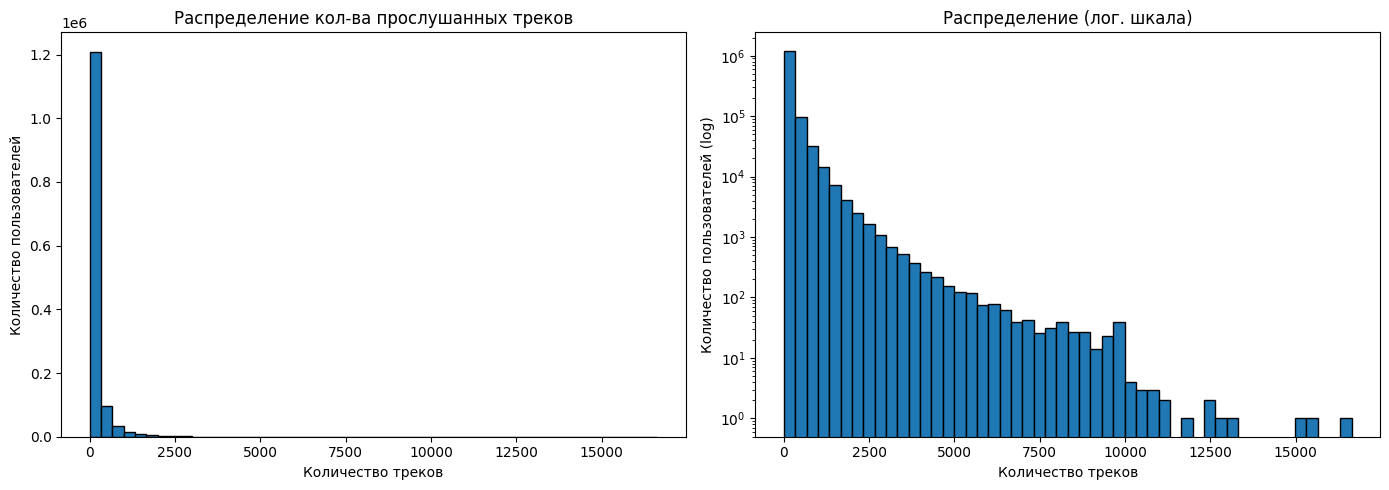

: 

In [ ]:
# Проверим распределение количества прослушанных треков по пользователям ДО фильтрации

# Подсчитываем количество треков, с которыми взаимодействовал каждый пользователь
tracks_per_user = df_interactions.groupby("user_id")["track_id"].count()

# Выводим статистику по количеству событий на пользователя
print("=== Распределение количества прослушанных треков по пользователям ===")
print(tracks_per_user.describe())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения количества прослушанных треков на линейной шкале
axes[0].hist(tracks_per_user, bins=50, edgecolor="black")
axes[0].set_title("Распределение кол-ва прослушанных треков")
axes[0].set_xlabel("Количество треков")
axes[0].set_ylabel("Количество пользователей")

# Гистограмма распределения количества прослушанных треков на логарифмической шкале
axes[1].hist(tracks_per_user, bins=50, edgecolor="black", log=True)
axes[1].set_title("Распределение (лог. шкала)")
axes[1].set_xlabel("Количество треков")
axes[1].set_ylabel("Количество пользователей (log)")

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# Проверяем количество ивентов на пользователя и фильтруем пользователей с менее чем 2 событиями
# Выводим статистику по количеству событий на пользователя
print(f"Users with 1 event: {(tracks_per_user == 1).sum()}")                                                                                                                                                                                                   
print(f"Users with 2+ events: {(tracks_per_user >= 2).sum()}")                                                                                                                                                                                                 
print(f"Min events per user: {tracks_per_user.min()}")    
rows_before = len(df_interactions)
print(f"Rows before: {rows_before}")                                                                                                                                                                   

# Оставляем только пользователей с 2 и более событиями
valid_users = set(tracks_per_user[tracks_per_user >= 2].index)
mask = df_interactions["user_id"].isin(valid_users)
del valid_users
df_interactions = df_interactions.loc[mask].reset_index(drop=True)
del mask, valid_users, df_tracks, df_catalog
gc.collect()

# Пересчитываем tracks_per_user после фильтрации
tracks_per_user = df_interactions.groupby("user_id")["track_id"].count()

# Проверяем сколько строк осталось после фильтрации и какую пропорцию от изначального количества данных это составляет
rows_after = len(df_interactions)
print(f"Rows after: {len(df_interactions)}")
print(f"Proportion kept ~: {rows_after / rows_before * 100:.2f}%")

Users with 1 event: 849
Users with 2+ events: 1372372
Min events per user: 1
Rows before: 222629898


In [ ]:
check_memory_imprint()

Available RAM: 14.912872314453125 GB
Total RAM: 31.340160369873047 GB
Used RAM: 16.427288055419922 GB
RAM usage percent: 52.4 %


: 

In [ ]:
if s3_exists("interactions_threshold_filtered.parquet"):
    n_before = len(df_interactions)
    del df_interactions          # free memory before loading
    import gc; gc.collect()                                                                                                                                                              
    df_interactions = from_s3("interactions_threshold_filtered.parquet")

else:                                                                                                                                                                                    
    percentiles = tracks_per_user.quantile([0.95, 0.99, 0.999, 1.0])
    print("=== Треков на пользователя по процентилям ===")
    print(percentiles)                                                                                                                                                                   
    print(f"\nСредняя: {tracks_per_user.mean():.1f}")
    print(f"Медиана: {tracks_per_user.median():.1f}")                                                                                                                                    
                                                                                                                                                                                           
    threshold = tracks_per_user.quantile(0.99)
    print(f"\nПорог 99-го процентиля: {threshold}")                                                                                                                                      
                
    n_before = len(df_interactions)                                                                                                                                                      
    normal_users = set(tracks_per_user[tracks_per_user <= threshold].index)
    mask = df_interactions["user_id"].isin(normal_users)                                                                                                                                 
    del normal_users
    df_interactions = df_interactions.loc[mask].reset_index(drop=True)                                                                                                                   
    del mask
    import gc; gc.collect()                                                                                                                                                              
                                                                                                                                                                                        
    to_s3(df_interactions, "interactions_threshold_filtered.parquet")

print(f"Строк до: {n_before}")
print(f"Строк после:  {len(df_interactions)}")
print(f"Оставленная пропорция: {len(df_interactions) / n_before * 100:.2f}%")

=== Треков на пользователя по процентилям ===
0.950      650.00
0.990     1576.00
0.999     4060.78
1.000    16637.00
Name: track_id, dtype: float64

Средняя: 162.1
Медиана: 55.0

Порог 99-го процентиля: 1576.0


In [ ]:
# Проверим распределение количества прослушанных треков по пользователям ПОСЛЕ фильтрации

# Подсчитываем количество треков, с которыми взаимодействовал каждый пользователь
tracks_per_user = df_interactions.groupby("user_id")["track_id"].count()

# Выводим статистику по количеству событий на пользователя
print("=== Распределение количества прослушанных треков по пользователям ===")
print(tracks_per_user.describe())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения количества прослушанных треков на линейной шкале
axes[0].hist(tracks_per_user, bins=50, edgecolor="black")
axes[0].set_title("Распределение кол-ва прослушанных треков")
axes[0].set_xlabel("Количество треков")
axes[0].set_ylabel("Количество пользователей")

# Гистограмма распределения количества прослушанных треков на логарифмической шкале
axes[1].hist(tracks_per_user, bins=50, edgecolor="black", log=True)
axes[1].set_title("Распределение (лог. шкала)")
axes[1].set_xlabel("Количество треков")
axes[1].set_ylabel("Количество пользователей (log)")

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# Проверяем диапазон дат в данных о взаимодействиях и наличие аномальных дат (например, будущих дат или дат слишком ранних)
print("=== Диапазон дат ===") 
print(f"Минимальная: {df_interactions['started_at'].min()}")                                                                                                                                                                                                      
print(f"Максимальная: {df_interactions['started_at'].max()}")
                                                                                                                                                                                                                                                                
# Распределение событий по месяцам, чтобы заметить аномалии в датах (например, если есть события в будущем или слишком ранние)                                                                                                                                                                                                                     
print("\n=== Ивентов по месяцам ===")                                                                                                                                                                                                                            
print(df_interactions['started_at'].dt.to_period('M').value_counts().sort_index())                                                                                                                                                                             
                                                                                                                                                                                                                                                            
# Проверяем наличие событий за пределами ожидаемого диапазона (например, до 2022 года или после 2022 года)                                                                                                                                                                                                             
date_min = pd.Timestamp("2022-01-01")                                                                                                                                                                                                                        
date_max = pd.Timestamp("2022-12-31")                                                                                                                                                                                                                          
                                                                                                                                                                                                                                                            
outlier_dates = df_interactions[                                                                                                                                                                                                                               
    (df_interactions['started_at'] < date_min) |                                                                                                                                                                                                             
    (df_interactions['started_at'] > date_max)                                                                                                                                                                                                                 
]
print(f"\nСобытий вне диапазона {date_min.date()} — {date_max.date()}: {len(outlier_dates)}")                                                                                                                                                                         

# Если есть аномальные даты, выводим их статистику и удаляем эти строки из данных о взаимодействиях
if len(outlier_dates) > 0:                                                                                                                                                                                                                                     
    print(outlier_dates['started_at'].describe())                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                
    # Удаляем строки с аномальными датами и проверяем сколько строк осталось после фильтрации
    n_before = len(df_interactions)                                                                                                                                                                                                                            
    df_interactions = df_interactions[                                                                                                                                                                                                                         
        (df_interactions['started_at'] >= date_min) &                                                                                                                                                                                                          
        (df_interactions['started_at'] <= date_max)                                                                                                                                                                                                            
    ]                                                                                                                                                                                                                                                          
    print(f"\nСтрок до фильтрации: {n_before}")                                                                                                                                                                                                                      
    print(f"Строк после фильтрации:  {len(df_interactions)}")
    print(f"Пропорционально оставили: {len(df_interactions) / n_before * 100:.2f}%")                                                                                                                                                                                    
else:
    print("Нет аномальных дат — фильтрация не требуется.")

Наиболее популярные треки

In [ ]:
# --- 2. Наиболее популярные треки ---
track_listen_counts = df_interactions.groupby("track_id")["user_id"].count().reset_index()
track_listen_counts.columns = ["track_id", "listen_count"]
track_listen_counts = track_listen_counts.sort_values("listen_count", ascending=False)

# Добавим имена треков
track_names = df_tracks_info.rename(columns={"id": "track_id", "name": "track_name"})[["track_id", "track_name"]]
top_tracks = track_listen_counts.head(20).merge(track_names, on="track_id", how="left")

# Выводим топ-20 популярных треков
print("=== Топ-20 популярных треков ===")
print(top_tracks.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 6))
labels = top_tracks.apply(lambda r: f"{r['track_name']}" if pd.notna(r['track_name']) else str(r['track_id']), axis=1)
ax.barh(labels[::-1], top_tracks["listen_count"][::-1])
ax.set_xlabel("Количество прослушиваний")
ax.set_title("Топ-20 популярных треков")
plt.tight_layout()
plt.show()
plt.close()

Наиболее популярные жанры

In [ ]:
# --- 3. Наиболее популярные жанры ---

# Раскроем жанры: каждый трек может иметь несколько жанров
track_genres = df_tracks.explode("genres")[["track_id", "genres"]].rename(columns={"genres": "genre_id"})
# Присоединим прослушивания
genre_listens = track_genres.merge(df_interactions[["track_id"]], on="track_id")
genre_listen_counts = genre_listens.groupby("genre_id").size().reset_index(name="listen_count")
genre_listen_counts = genre_listen_counts.sort_values("listen_count", ascending=False)

# Добавим имена жанров
genre_names = df_genres_info.rename(columns={"id": "genre_id", "name": "genre_name"})[["genre_id", "genre_name"]]
top_genres = genre_listen_counts.head(20).merge(genre_names, on="genre_id", how="left")

# Выводим топ-20 популярных жанров
print("=== Топ-20 популярных жанров ===")
print(top_genres.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_genres["genre_name"][::-1], top_genres["listen_count"][::-1])
ax.set_xlabel("Количество прослушиваний")
ax.set_title("Топ-20 популярных жанров")
plt.tight_layout()
plt.show()
plt.close()

Треки, которые никто не прослушал

In [ ]:
# --- 4. Треки, которые никто не прослушал ---

# Получаем множества треков, которые были прослушаны и все треки из каталога
listened_track_ids = set(df_interactions["track_id"])
all_track_ids = set(df_tracks["track_id"])
unlistened_track_ids = all_track_ids - listened_track_ids

# Выводим статистику по трекам, которые никто не прослушал
print("=== Треки, которые никто не прослушал ===")
print(f"Всего треков: {len(all_track_ids)}")
print(f"Прослушанных треков: {len(listened_track_ids)}")
print(f"Непрослушанных треков: {len(unlistened_track_ids)}")
print(f"Доля непрослушанных: {len(unlistened_track_ids) / len(all_track_ids) * 100:.4f}%")
print()

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [ ]:
# Добавим к трекам названия, имена исполнителей и жанров для дальнейшего анализа и моделирования
items = df_tracks.merge(track_names, on="track_id", how="left")

# Создаем словари для быстрого получения имен исполнителей и жанров по их ID
artist_id_to_name = df_artists_info.set_index("id")["name"].to_dict()
genre_id_to_name = df_genres_info.set_index("id")["name"].to_dict()

# Преобразуем списки ID исполнителей и жанров в списки имен для каждого трека
items["artist_names"] = items["artists"].apply(
    lambda ids: [artist_id_to_name[i] for i in ids if i in artist_id_to_name]
)
items["genre_names"] = items["genres"].apply(
    lambda ids: [genre_id_to_name[i] for i in ids if i in genre_id_to_name]
)

events = df_interactions.copy()

# Переименуем колонки для удобства дальнейшей работы

items = items.rename(columns={"track_id": "item_id"})
events = events.rename(columns={"track_id": "item_id"})
df_albums_info = df_albums_info.rename(columns={"id": "album_id", "name": "album_name"})

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [ ]:
# Сохраняем подготовленные датафреймы в parquet файлы для дальнейшего использования в моделировании
to_s3(items, "items.parquet")
to_s3(events, "events.parquet")
to_s3(df_tracks_info, "tracks_info.parquet")
to_s3(df_albums_info, "albums_info.parquet")
to_s3(df_genres_info, "genres_info.parquet")

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [ ]:
# Очистка памяти
# Удаляем все переменные, которые больше не нужны после сохранения данных в parquet.
# Этап 3 загружает данные заново из items.parquet и events.parquet.

for var in [
    "df_tracks", "df_catalog", "df_interactions",
    "df_tracks_info", "df_albums_info", "df_artists_info", "df_genres_info",
    "items", "events",
    "tracks_per_user", "track_listen_counts", "track_names", "top_tracks",
    "track_genres", "genre_listens", "genre_listen_counts", "genre_names", "top_genres",
    "listened_track_ids", "all_track_ids", "unlistened_track_ids",
    "known_album_ids", "known_artist_ids", "known_genre_ids",
    "all_album_ids", "all_artist_ids", "all_genre_ids",
    "unknown_albums", "unknown_artists", "unknown_genres",
    "has_unknown_album", "has_unknown_artist", "has_unknown_genre", "df_tracks_unknown",
    "valid_users", "normal_users", "percentiles", "threshold",
    "artist_id_to_name", "genre_id_to_name",
    "interaction_tracks", "known_tracks", "missing_in_tracks"
]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

Если память всё ещё не освобождается достаточно:
1. Перезапустите kernel
2. Продолжите выполнение с Этапа 3 внизу где импортируем библиотеки еще раз

# === ЭТАП 3 ===

In [ ]:
# Повторно импортируем библиотеки для следующего этапа моделирования
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import pickle
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import sys
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from sklearn.metrics import ndcg_score
from collections import Counter
from catboost import CatBoostClassifier, Pool
import boto3
import io
import os
from dotenv import load_dotenv
from botocore.client import Config
load_dotenv(override=True)


pd.options.mode.chained_assignment = None

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [ ]:
# Импортируем подготовленные данные из parquet файлов для дальнейшего моделирования
items = from_s3("items.parquet")
events = from_s3("events.parquet")
tracks_info = from_s3("tracks_info.parquet")
albums_info = from_s3("albums_info.parquet")
genres_info = from_s3("genres_info.parquet")

# Разделяем данные

Разбиваем данные на тренировочную, тестовую выборки.

In [ ]:
# Разделим данные на обучающую и тестовую выборки по времени

# Устанавливаем дату для разделения данных на обучающую и тестовую выборки
train_test_global_time_split_date = pd.to_datetime("2022-12-16")
train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date

# Разделяем события на обучающую и тестовую выборки
events_train = events[train_test_global_time_split_idx]
events_test = events[~train_test_global_time_split_idx]

# Выделяем пользователей, которые есть в обучающей и тестовой выборках
users_train = events_train["user_id"].drop_duplicates()
users_test = events_test["user_id"].drop_duplicates()

# Находим общих пользователей, которые есть и в обучающей, и в тестовой выборках
common_users = set(users_train) & set(users_test)

# Находим "холодных" пользователей, которые есть только в тестовой выборке и отсутствуют в обучающей
cold_users = set(users_test) - set(users_train)

# Выводим статистику по пользователям в обучающей и тестовой выборках
print(f"Количество пользователей в обучающем наборе: {len(users_train)}")
print(f"Количество пользователей в тестовом наборе: {len(users_test)}")
print(f"Количество общих пользователей в обоих наборах: {len(common_users)}")
print(f"Количество холодных пользователей (только в тесте): {len(cold_users)}")

to_s3(events_train, "events_train.parquet")
to_s3(events_test, "events_test.parquet")

# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [ ]:
# Функция для нахождения наиболее популярных треков
def load_or_compute_item_popularity(events, save_path, half_life=60):

    # Если файл уже существуют, загружаем их, чтобы не пересчитывать
    if s3_exists(save_path):
        popularity = from_s3(save_path)

    # Если файлов нет, то вычисляем популярность треков
    else:
        # Находим дату последнего взаимодействия
        reference_date = events["started_at"].max()

        # Считаем, сколько дней назад произошло каждое взаимодействие
        days_ago = (reference_date - events["started_at"]).dt.days

        # Добавляем экспоненциальное затухание для взвешивания взаимодействий
        # Более свежие взаимодействия получают вес ближе к 1, а более старые — ближе к 0
        weights = np.power(0.5, days_ago / half_life)

        # Вычисляем популярность треков, учитывая количество уникальных пользователей и сумму весов взаимодействий (recency score)
        popularity = (
            events.assign(weights=weights)
            .groupby("item_id")
            .agg(users=("user_id", "nunique"), recency_score=("weights", "sum"))
            .reset_index()
        )

        # Нормализуем количество пользователей и recency score для объединения в единую метрику популярности
        scaler = MinMaxScaler()
        popularity[["users_norm", "recency_norm"]] = scaler.fit_transform(
            popularity[["users", "recency_score"]]
        )
        popularity["popularity_score"] = (
            0.5 * popularity["users_norm"] + 0.5 * popularity["recency_norm"]
        )

        # Сортируем треки по популярности
        popularity = popularity.sort_values("popularity_score", ascending=False)

        # Сохраняем популярность треков в parquet файл
        to_s3(popularity, save_path)

    return popularity


# Функция для получения топ-k популярных треков
def get_top_k_popular_items(
        item_popularity,
        items,
        albums_info,
        save_path,    
        k=100
    ):
    # Если файл уже существует, загружаем его, чтобы не пересчитывать
    if s3_exists(save_path):
        top_k_pop_items = from_s3(save_path)
    
    else:
        # Берем топ-100 популярных треков по метрике популярности
        top_k_pop_items = item_popularity.head(k)

         # Добавляем к топ-100 популярных треков их названия, имена исполнителей, жанров и альбомов
        top_k_pop_items = top_k_pop_items.merge(
            items[["item_id", "artist_names", "genre_names", "albums"]],
            on="item_id",                                  
            how="left"                                     
        )

        # Преобразуем списки ID альбомов в списки имен альбомов для топ-100 популярных треков
        album_id_to_name = albums_info.set_index("album_id")["album_name"].to_dict()                          
        top_k_pop_items["album_names"] = top_k_pop_items["albums"].apply(
            lambda ids: [album_id_to_name[i] for i in ids if i in album_id_to_name]                          
        )

        # Убираем колонку с ID альбомов, так как теперь у нас есть колонка с именами альбомов 
        top_k_pop_items = top_k_pop_items.drop(columns=["albums"])

        # Сохраняем топ-100 популярных треков с их метрикой популярности и дополнительной информацией в parquet файл
        to_s3(top_k_pop_items, save_path)

    return top_k_pop_items

# Получаем топ-100 популярных треков с их метрикой популярности
item_popularity = load_or_compute_item_popularity(events_train, "item_popularity.parquet")
top_k_pop_items = get_top_k_popular_items(item_popularity, items, albums_info, save_path="top_popular.parquet", k=100)

top_k_pop_items.head()

In [ ]:
# Для холодных пользователей проверим, сколько из их взаимодействий в тестовой выборке
# можно было бы рекомендовать, если бы мы рекомендовали топ-100 популярных треков из обучающей выборки.

# Находим все события в тестовой выборке, которые принадлежат холодным пользователям
cold_users_events_with_recs = \
    events_test[events_test["user_id"].isin(cold_users)] \
    .merge(top_k_pop_items[["item_id", "popularity_score"]], on="item_id", how="left")

# Считаем, сколько из этих событий можно было бы рекомендовать, если бы мы рекомендовали топ-100 популярных треков
cold_user_items_no_pop_score_idx = cold_users_events_with_recs["popularity_score"].isnull()
cold_user_recs = cold_users_events_with_recs[~cold_user_items_no_pop_score_idx] \
    [["user_id", "item_id", "popularity_score"]]

# Выводим статистику по тому, сколько событий холодных пользователей в тестовой выборке можно было бы рекомендовать
matching_recs_count = cold_user_recs.shape[0]
total_cold_user_events = cold_users_events_with_recs.shape[0]
matching_recs_ratio = matching_recs_count / total_cold_user_events

cold_user_recs.head()

In [ ]:
# Посчитаем покрытие холодных пользователей рекомендациями

cold_users_hit_ratio = cold_users_events_with_recs.groupby("user_id").agg(
    hits=("popularity_score", lambda x: (~x.isnull()).mean())
)

print(f"Доля пользователей без релевантных рекомендаций: {(cold_users_hit_ratio == 0).mean().iat[0]:.2f}")
print(f"Количество событий холодных пользователей, которые можно было бы рекомендовать: {matching_recs_count:.2f}")
print(f"Среднее покрытие пользователей с хотя бы одним попаданием: {cold_users_hit_ratio[cold_users_hit_ratio != 0].mean().iat[0]:.2f}")

In [ ]:
# Очистка памяти
for var in ["reference_date", "days_ago", "half_life", "weights", 
            "events_weighted", "item_popularity", "top_k_pop_items", 
            "cold_user_items_no_pop_score_idx", "cold_user_recs", 
            "album_id_to_name", "cold_users_hit_ratio"
        ]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Кодируем идентификаторы пользователей и треков в числовой формат для использования в модели

# Функция для кодирования колонки с помощью LabelEncoder.
def encode_column(fit_df, col, *transform_dfs):
    encoder = LabelEncoder()
    encoder.fit(fit_df[col])
    for df in transform_dfs:
        df[f"{col}_enc"] = encoder.transform(df[col])
    return encoder

# Кодируем айди пользователей
user_encoder = encode_column(events, "user_id", events_train, events_test)
# Кодируем айди треков
item_encoder = encode_column(items, "item_id", items, events_train, events_test)

In [ ]:
# Функция для построения разреженной матрицы взаимодействий
def build_interaction_matrix(df, user_encoder, item_encoder):
    return csr_matrix(
        (
            np.ones(len(df), dtype=np.float32),
            (df["user_id_enc"], df["item_id_enc"]),
        ),
        shape=(len(user_encoder.classes_), len(item_encoder.classes_)),
    )

# Создаем матрицу взаимодействий для обучающей выборки
user_item_matrix_train = build_interaction_matrix(events_train, user_encoder, item_encoder)

# Вычисляем размер разреженной матрицы взаимодействий в памяти
train_matrix_size = sum([sys.getsizeof(i) for i in user_item_matrix_train.data])/1024**3

print(f"Размер матрицы взаимодействий: {train_matrix_size:.2f} GB")
user_item_matrix_train

# Персональные

Рассчитаем персональные рекомендации.

In [ ]:
# Загружаем обученную модель ALS из файла, если она уже была сохранена или обучаем модель, если файла нет

try:
    als_model = from_s3("als_model.pkl")
except Exception:
    als_model = AlternatingLeastSquares(factors=50, iterations=50, regularization=0.01, random_state=0)
    als_model.fit(user_item_matrix_train)

    to_s3(als_model, "als_model.pkl")

In [ ]:
# Функция для получения рекомендаций для пользователя на основе обученной модели ALS

def get_recommendations_als(user_item_matrix, model, user_id, user_encoder, item_encoder, include_seen=True, n=5):
    user_id_enc = user_encoder.transform([user_id])[0]
    recommendations = model.recommend(
        user_id_enc,
        user_item_matrix[user_id_enc],
        filter_already_liked_items=not include_seen,
        N=n
    )
    recommendations = pd.DataFrame({"item_id_enc": recommendations[0], "score": recommendations[1]})
    recommendations["item_id"] = item_encoder.inverse_transform(recommendations["item_id_enc"])
    return recommendations

In [ ]:
# Выбираем случайного пользователя и выводим его историю взаимодействий и рекомендации от модели

# Функция для получения истории взаимодействий пользователя
def get_user_history(user_id, events, items):
    return (
        events
        .query("user_id == @user_id")
        .merge(items[["item_id", "artist_names", "track_name", "genre_names"]], on="item_id")
        [["item_id", "artist_names", "track_name", "genre_names", "started_at"]]
        .sort_values("started_at")
    )


# Функция для получения рекомендаций для пользователя
def get_user_recommendations(
        user_id, 
        events, 
        items, 
        user_item_matrix, 
        model, 
        user_encoder, 
        item_encoder, 
        include_seen,
        n=20):
    
    # Находим треки, с которыми пользователь уже взаимодействовал
    seen_items = set(events.query("user_id == @user_id")["item_id"])

    # Получаем рекомендации от модели
    recs = get_recommendations_als(
        user_item_matrix, model,
        user_id, user_encoder, item_encoder,
        include_seen=include_seen, n=n
    )

    # Добавляем к рекомендациям информацию о треках из каталога
    recs = recs.merge(items[["item_id", "artist_names", "track_name", "genre_names"]], on="item_id")
    recs["seen"] = recs["item_id"].isin(seen_items)

    # Выбираем только нужные колонки для отображения
    return recs[["item_id", "artist_names", "track_name", "genre_names", "score", "seen"]]

# Выбираем случайного пользователя
random_user_id = np.random.choice(events_train["user_id"].unique())                                                                         
print(f"User ID: {random_user_id}\n")

# Получаем историю взаимодействий пользователя и добавляем к ней информацию о треках из каталога
print("=== История пользователя ===")
display(get_user_history(random_user_id, events_train, items))

# Получаем рекомендации от модели ALS для этого пользователя, исключая уже прослушанные треки
print("\n=== Рекомендации ALS ===")
display(get_user_recommendations(
    random_user_id, events_train, items,
    user_item_matrix_train, als_model,
    user_encoder, item_encoder, 
    include_seen=False, n=20
))

In [ ]:
# Получаем рекомендации от модели ALS для всех пользователей и сохраняем

# Кодируем все user_id в последовательные числа
user_ids_encoded = range(len(user_encoder.classes_))

def get_all_recommendations_als(
        save_path, 
        als_model, 
        user_encoder,
        item_encoder,
        user_item_matrix,
        N=100,
        filter_already_liked_items=False
    ):
    # Если рекомендации уже были сохранены в parquet файл, загружаем их, чтобы не пересчитывать
    if s3_exists(save_path):
        recommendations = from_s3(save_path)

    # В противном случае, получаем рекомендации от модели
    else:
        recommendations = als_model.recommend(
            user_ids_encoded,
            user_item_matrix[user_ids_encoded],
            filter_already_liked_items=filter_already_liked_items, 
            N=N
        )

        # Преобразуем рекомендации в датафрейм для удобства
        item_ids_enc = recommendations[0]
        als_scores = recommendations[1]

        recommendations = pd.DataFrame({
            "user_id_enc": user_ids_encoded,
            "item_id_enc": item_ids_enc.tolist(),
            "score": als_scores.tolist()
        })
        recommendations = recommendations.explode(["item_id_enc", "score"], ignore_index=True)

        recommendations["item_id_enc"] = recommendations["item_id_enc"].astype("int")
        recommendations["score"] = recommendations["score"].astype("float")

        recommendations["user_id"] = user_encoder.inverse_transform(recommendations["user_id_enc"])
        recommendations["item_id"] = item_encoder.inverse_transform(recommendations["item_id_enc"])
        recommendations = recommendations.drop(columns=["user_id_enc", "item_id_enc"])

        recommendations = recommendations[["user_id", "item_id", "score"]]
        to_s3(recommendations, save_path)

    return recommendations


# Получаем рекомендации от модели ALS для всех пользователей
als_recommendations = get_all_recommendations_als(
    save_path="personal_als.parquet",
    als_model=als_model,
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    user_item_matrix=user_item_matrix_train
)

# Выводим первые строки рекомендаций
als_recommendations.head()

In [ ]:
# Очистка памяти
for var in [
    'user_item_matrix_train', 'random_user_id',
    'user_history', 'seen_items', 'recs', 'user_ids_encoded',
    'item_ids_enc', 'als_scores', 'als_recommendations',
    'events'
]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
# Функция для получения похожих треков на основе обученной модели ALS

# Выбираем трек для которого будем искать похожие (я выбрал тот который знал)
test_item_id = 29544272

# Функция для получения похожих треков
def get_similar_items_one_user(item_id, n=5):
    item_id_enc = item_encoder.transform([item_id])[0]
    item_ids_enc, similarities = als_model.similar_items(item_id_enc, N=n)

    similar_items_df = pd.DataFrame({
        "item_id_enc": item_ids_enc,
        "similarity": similarities
    })

    similar_items_df["item_id"] = item_encoder.inverse_transform(similar_items_df["item_id_enc"])

    similar_items_df = similar_items_df.merge(
        items[["item_id", "artist_names", "track_name", "genre_names"]],
        on="item_id",
        how="left"
    )

    return similar_items_df[["item_id", "artist_names", "track_name", "genre_names", "similarity"]]

# Проверяем функцию на выбранном треке
get_similar_items_one_user(test_item_id)

In [ ]:
# Функция для получения похожих треков для всех треков в обучающей выборке и сохранения их в parquet файл
def compute_similar_items_all_users(als_model, events_train, item_encoder, max_similar_items=10, save_path="similar.parquet"):
    
    # Получаем уникальные закодированные идентификаторы треков из обучающей выборки
    train_item_ids_enc = events_train["item_id_enc"].unique()

    # Получаем похожие треки для каждого трека из обучающей выборки, используя модель
    similar_items = als_model.similar_items(train_item_ids_enc, N=max_similar_items+1)

    # Преобразуем результаты в датафрейм для удобства
    sim_item_ids_enc = similar_items[0]
    sim_item_scores = similar_items[1]

    similar_items = pd.DataFrame({
        "item_id_enc": train_item_ids_enc,
        "sim_item_id_enc": sim_item_ids_enc.tolist(),
        "score": sim_item_scores.tolist()
    })

    similar_items = similar_items.explode(["sim_item_id_enc", "score"], ignore_index=True)

    similar_items["sim_item_id_enc"] = similar_items["sim_item_id_enc"].astype("int")
    similar_items["score"] = similar_items["score"].astype("float")

    similar_items["item_id_1"] = item_encoder.inverse_transform(similar_items["item_id_enc"])
    similar_items["item_id_2"] = item_encoder.inverse_transform(similar_items["sim_item_id_enc"])
    similar_items = similar_items.drop(columns=["item_id_enc", "sim_item_id_enc"])

    similar_items = similar_items.query("item_id_1 != item_id_2")

    # Сохраняем похожие треки в parquet файл для дальнейшего использования
    to_s3(similar_items, save_path)

    return similar_items


# Если похожие треки уже были сохранены в parquet файл, загружаем их, чтобы не пересчитывать
if s3_exists("similar.parquet"):
    similar_items = from_s3("similar.parquet")
# Если нет то находим их заново для всех треков в обучающей выборке и сохраняем в parquet файл
else:
    similar_items = compute_similar_items_all_users(
        als_model, events_train, item_encoder,
        max_similar_items=10, save_path="similar.parquet"
    )

# Выводим первые строки похожих треков
similar_items.head()

In [ ]:
# Очистка памяти
for var in ['test_item_id', 'similar_items']:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Функция для трансформации событий и рекомендаций в формат, удобный для расчета бинарных метрик
def process_for_binary_metrics(events_train, events_test, recs=None, top_popular=None, top_k=None):
    if (recs is None) == (top_popular is None):
        raise ValueError("Должен быть передан либо recs, либо top_popular, но не оба сразу.")
    
    # Добавляем колонку "gt" в тестовые события, которая будет указывать, что эти события являются истинными взаимодействиями
    events_test["gt"] = True
    
    # Если переданы рекомендации от модели, то объединяем их с тестовыми событиями по пользователям и трекам
    if recs is not None:
        # Находим общих пользователей, для которых есть и тестовые события, и рекомендации от модели
        common_users = set(events_test["user_id"]) & set(recs["user_id"])
        print(f"Common users: {len(common_users)}")

        # Оставляем только тестовые события и рекомендации для общих пользователей, чтобы можно было сравнивать их между собой
        events_for_common_users = events_test[events_test["user_id"].isin(common_users)].copy()
        recs_for_common_users = recs[recs["user_id"].isin(common_users)].copy()

        # Сортируем рекомендации от модели по пользователям и убыванию их оценок
        recs_for_common_users = recs_for_common_users.sort_values(["user_id", "score"], ascending=[True, False])

        # Оставляем только те тестовые события для общих пользователей, которые относятся к трекам, которые были в обучающей выборке
        events_for_common_users = events_for_common_users[events_for_common_users["item_id"].isin(events_train["item_id"].unique())]

        # Если указано top_k, то оставляем только топ-k рекомендаций от модели для каждого пользователя
        if top_k is not None:
            recs_for_common_users = recs_for_common_users.groupby("user_id").head(top_k)

        # Объединяем тестовые события и рекомендации от модели для общих пользователей по пользователям и трекам
        events_for_binary_metrics = events_for_common_users[["user_id", "item_id", "gt"]].merge(
            recs_for_common_users[["user_id", "item_id", "score"]], 
            on=["user_id", "item_id"], how="outer")

    # Если переданы только топ популярных треков, то объединяем их с тестовыми событиями по трекам
    else:
        # Если указано top_k, то оставляем только топ-k популярных треков
        top_popular_df = top_popular.copy()
        top_popular_df = top_popular_df.sort_values("popularity_score", ascending=False).head(top_k)
        events_test = events_test[events_test["item_id"].isin(events_train["item_id"].unique())]

        # Объединяем тестовые события с топ популярными треками по трекам, так как рекомендации от модели в данном случае одинаковые для всех пользователей
        events_for_binary_metrics = events_test[["user_id", "item_id", "gt"]].merge(
            top_popular_df[["item_id", "popularity_score"]], 
            on=["item_id"], how="outer")
        events_for_binary_metrics.rename(columns={"popularity_score": "score"}, inplace=True)
    
    # Заполняем пропуски в колонке "gt" и подсчитываем бинарные метрики для расчета TP, FP и FN
    events_for_binary_metrics["gt"] = events_for_binary_metrics["gt"].fillna(False)
    events_for_binary_metrics["pr"] = ~events_for_binary_metrics["score"].isnull()
    
    events_for_binary_metrics["tp"] = events_for_binary_metrics["gt"] & events_for_binary_metrics["pr"]
    events_for_binary_metrics["fp"] = ~events_for_binary_metrics["gt"] & events_for_binary_metrics["pr"]
    events_for_binary_metrics["fn"] = events_for_binary_metrics["gt"] & ~events_for_binary_metrics["pr"]

    return events_for_binary_metrics
            
# Считываем рекомендации от модели ALS из parquet файла
als_recommendations = from_s3("personal_als.parquet")

# Трансформируем события и рекомендации в формат, удобный для расчета бинарных метрик
events_recs_for_binary_metrics = process_for_binary_metrics(
    events_train=events_train,
    events_test=events_test, 
    recs=als_recommendations, 
    top_k=10
)

In [ ]:
# Функция для расчета precision and recall@n
def compute_cls_metrics(events_recs_for_binary_metrics):
    groupper = events_recs_for_binary_metrics.groupby("user_id")

    precision = groupper["tp"].sum() / (groupper["tp"].sum() + groupper["fp"].sum())
    precision = precision.fillna(0).mean()

    recall = groupper["tp"].sum() / (groupper["tp"].sum() + groupper["fn"].sum())
    recall = recall.fillna(0).mean()

    return precision, recall

# Вычисляем precision@10 и recall@10 для рекомендаций от модели ALS
precision_at_10, recall_at_10 = compute_cls_metrics(events_recs_for_binary_metrics)
print(f"Precision@10: {precision_at_10:.4f}, Recall@10: {recall_at_10:.4f}")

In [ ]:
# Функция для расчета NDCG@k
def compute_ndcg(gt: pd.Series, score: pd.Series, k):                                                                                                                                                                                                                                                                                                                                                   
    if len(gt) < 2 or gt.sum() == 0:                                                                                                                                                                    
        return np.nan                                                                                                                                                                                   
                                                                                                                                                                                                    
    ndcg = ndcg_score(                                                                                                                                                                  
        np.asarray([gt.to_numpy()]),                                                                                                                                                                  
        np.asarray([score.to_numpy()]),                                                                                                                                                                 
        k=k                                                                                                                                                                                           
    )                                                                                                                                                                                                   
    return ndcg

# Функция для вычисления NDCG@k для всех пользователей
def compute_ndcg_for_all_events(
    events_recs_for_binary_metrics,
    k=10):
    # Вычисляем NDCG@10 для рекомендаций от модели ALS
    events_for_ndcg = events_recs_for_binary_metrics.copy()
    events_for_ndcg["score"] = events_for_ndcg["score"].fillna(0)
    events_for_ndcg["gt"] = events_for_ndcg["gt"].astype(float)

    ndcg_at_k = (                                                                                                                                                                                           
        events_for_ndcg                                                                                                                                                                                     
        .groupby("user_id")                                                                                                                                                                                 
        .apply(lambda x: compute_ndcg(x["gt"], x["score"], k=k))
    )

    return ndcg_at_k

# Выводим NDCG@10 для рекомендаций
ndcg_at_10 = compute_ndcg_for_all_events(events_recs_for_binary_metrics, k=10)

# Выводим среднее значение NDCG@10 и количество пользователей, для которых NDCG было вычислено
print(f"NDCG@10: {ndcg_at_10.mean():.4f}")                                                                                                                                                                
print(f"Количество юзеров для которых подсчитали NDCG: {ndcg_at_10.notna().sum()} / {len(ndcg_at_10)}")

In [ ]:
# Очистка памяти
for var in ["events_recs_for_binary_metrics", "events_for_ndcg"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Функция для расчета покрытия рекомендаций от модели
def compute_coverage(recommendations, reference_events):
    cov_items = recommendations["item_id"].nunique() / reference_events["item_id"].nunique()
    return cov_items

# Вычисляем покрытие рекомендаций от модели
cov_items = compute_coverage(als_recommendations, events_train)
print(f"Покрытие: {cov_items:.2f}")

In [ ]:
# Вычисляем novelty@10 для рекомендаций от модели ALS

def compute_novelty(
    events_train,
    recs=None,
    top_popular=None,
    top_k=10
):
    if (recs is None) == (top_popular is None):
        raise ValueError("Должен быть передан либо recs, либо top_popular, но не оба сразу.")
    
    # Создаем множество пар (user_id, item_id) для всех взаимодействий в обучающей выборке, чтобы потом проверить, сколько из топ-10 рекомендаций уже были прослушаны пользователями
    scale = int(events_train["item_id"].max()) + 1
    listened_pairs = set(
        events_train["user_id"].to_numpy() * scale + events_train["item_id"].to_numpy()                               
    )
    
    if recs is not None:
        # Добавляем ранк для каждой рекомендации, чтобы потом отобрать топ-10 рекомендаций для каждого пользователя
        recs["rank"] = recs.groupby("user_id").cumcount() + 1
        top_k_recommendations = recs.query("rank <= @top_k").copy()

        top_k_listened = sum(
            u * scale + i in listened_pairs
            for u, i in zip(top_k_recommendations["user_id"], top_k_recommendations["item_id"])
        )
        novelty = 1 - top_k_listened / len(top_k_recommendations)

    else:
        top_k_recommendations = top_popular.sort_values("popularity_score", ascending=False).head(top_k)
        all_users = events_train["user_id"].unique()

        # Получаем массив item_id из топ-k популярных треков
        top_k_items = top_k_recommendations["item_id"].to_numpy()
        top_k_listened = sum(
            u * scale + i in listened_pairs
            for u in all_users                                                                                            
            for i in top_k_items
        )
        total_pairs = len(all_users) * len(top_k_items)
        novelty = 1 - top_k_listened / total_pairs

    return novelty  

novelty = compute_novelty(
    events_train=events_train,
    recs=als_recommendations
)
print(f"Novelty@10: {novelty:.4f}")

In [ ]:
# Сводим все метрики в словарь для удобства отображения
raw_als_metrics = {
    "precision@10": precision_at_10,
    "recall@10": recall_at_10,
    "ndcg@10": ndcg_at_10.mean(),
    "coverage": cov_items,
    "novelty@10": novelty
}

In [ ]:
# Очистка памяти
for var in ["listened_pairs", "als_recommendations"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Разделим тестовую выборку на две части для получения таргетов для модели ранжирования и для оценки метрик ранжирования
split_date_for_labels = pd.to_datetime("2022-12-22")

split_date_for_labels_idx = events_test["started_at"] < split_date_for_labels
events_labels = events_test[split_date_for_labels_idx]
events_test_2 = events_test[~split_date_for_labels_idx]

events_labels.drop(columns=["gt"], inplace=True)
events_test_2.drop(columns=["gt"], inplace=True)

# Убираем ненужные колонки из items
items.drop(columns=["artist_names", "artists", "albums"], inplace=True, errors="ignore")

In [ ]:
# Очистка памяти
for var in ["events_test"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Загружаем файл с событиями для инференса, если он уже был сохранен, или создаем его заново
if s3_exists("events_inference.parquet"):
    events_inference = from_s3("events_inference.parquet")
else:
    # events_labels.drop(columns=["gt", "target"], inplace=True)
    events_inference = pd.concat([events_train, events_labels], ignore_index=True)
    to_s3(events_inference, "events_inference.parquet")


# Загружаем файл с популярностью треков для инференса, если он уже был сохранен, или создаем его зановоs
item_popularity_inference = load_or_compute_item_popularity(events_inference, save_path="item_popularity_inference.parquet")

# Добавляем к items информацию о популярности треков для инференса
items = items.merge(item_popularity_inference[["item_id", "popularity_score"]], on="item_id", how="left")

# Берем первыми жанры из списка жанров для каждого трека, чтобы использовать их в качестве признаков для модели ранжирования
items['main_genre'] = items['genre_names'].apply(lambda x: x[0])
items.head()

items.head()

In [ ]:
# Очистка памяти
for var in ["events_inference", "weights_inference", "events_weighted_inference",
            "item_popularity_inference"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Добавляем к событиям для ранжирования информацию о жанрах треков и популярности треков
merged = events_labels.merge(items[['item_id', 'genre_names']], on='item_id', how='left')

# Разворачиваем списки жанров в отдельные строки, чтобы потом посчитать разнообразие жанров для каждого пользователя
merged_exploded = merged.explode('genre_names')

# Функция для расчета нормализованной энтропии Шеннона для списка жанров. Это позволит оценить разнообразие жанров, которые слушает пользователь.
# Чем выше значение, тем более разнообразные жанры слушает пользователь, а значение 0 будет означать, что пользователь слушает только один жанр.
def normalised_shannon_entropy(genres):
    genres = [g for g in genres if pd.notna(g)]
    if not genres:
        return 0.0
    counts = Counter(genres)
    total = sum(counts.values())
    n = len(counts)
    if n == 1:
        return 0.0
    probs = [c / total for c in counts.values()]
    raw = -sum(p * np.log2(p) for p in probs)
    return raw / np.log2(n)

# Вычисляем разнообразие жанров для каждого пользователя
diversity = (
    merged_exploded
    .groupby('user_id')['genre_names']
    .apply(normalised_shannon_entropy)
    .rename('user_listened_genre_diversity')
)

# Добавляем информацию о разнообразии жанров к событиям для ранжирования
events_labels = events_labels.merge(diversity, on='user_id', how='left')
# Добавляем информацию о популярности треков к событиям для ранжирования
events_labels = events_labels.merge(items[["item_id", "popularity_score"]], on="item_id", how="left")

events_labels.head()

In [ ]:
# Очистка памяти
for var in ["merged", "merged_exploded", "diversity",
            "events_train"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Функция для получения кандидатов для обучения модели ранжирования. Она объединяет рекомендации от модели ALS с событиями для ранжирования 
def get_candidates_for_train(
        events_labels,
        items,
        als_recommendations_path,
        save_path,
        negatives_per_user=4
    ):

    # Загружаем файл с кандидатами для обучения модели ранжирования, если он уже был сохранен, или создаем его заново
    if s3_exists(save_path):
        candidates_for_train = from_s3(save_path)

    else:
        # Загружаем рекомендации от модели ALS
        candidates = from_s3(als_recommendations_path)

        # Объединяем кандидатов с событиями для ранжирования, чтобы получить таргет для каждого кандидата
        candidates = candidates.merge(events_labels[["user_id", "item_id", "target"]].drop_duplicates(subset=["user_id", "item_id"]),
            on=["user_id", "item_id"],
            how="left"
        )

        # Добавляем таргет для модели ранжирования, который будет указывать, было ли взаимодействие между пользователем и треком в тестовой выборке
        candidates["target"] = candidates["target"].fillna(0).astype(int)

        # Объединяем кандидатов с событиями для ранжирования, чтобы получить таргет для каждого кандидата
        candidates = candidates.merge(
            events_labels[["user_id", "user_listened_genre_diversity"]].drop_duplicates("user_id"),
            on="user_id",
            how="left",
        )
        candidates["target"] = candidates["target"].fillna(0).astype(int)

        # Добавляем к кандидатам информацию об основных жанрах и популярности треков
        candidates = candidates.merge(items[["item_id", "popularity_score", "main_genre"]], on="item_id", how="left")

        # Оставляем только тех пользователей, у которых есть хотя бы одно положительное взаимодействие в тестовой выборке
        candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)

        # Для каждого пользователя оставляем все положительные примеры и случайно выбираем ограниченное количество отрицательных примеров
        candidates_for_train = pd.concat([
            candidates_to_sample.query("target == 1"),
            candidates_to_sample.query("target == 0") \
            .groupby("user_id") \
            .apply(lambda x: x.sample(negatives_per_user, random_state=0))
        ])

        # Сохраняем кандидатов для обучения модели ранжирования в parquet файл
        to_s3(candidates_for_train, save_path)

    return candidates_for_train


# Добавляем таргет для модели ранжирования, который будет указывать, было ли взаимодействие между пользователем и треком в тестовой выборке
events_labels["target"] = 1

# Получаем кандидатов для обучения модели ранжирования
candidates_for_train = get_candidates_for_train(
    events_labels,
    items,
    als_recommendations_path="personal_als.parquet",
    save_path="candidates_for_train.parquet"
)

candidates_for_train.head()

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [ ]:
# Обьявляем признаки и таргет для модели ранжирования
features = ["score", "user_listened_genre_diversity", "popularity_score", "main_genre"]
target = "target"

# Создаем пул для обучения модели CatBoost, указывая категориальные признаки
train_data = Pool(
    data=candidates_for_train[features],
    label=candidates_for_train[target],
    cat_features=["main_genre"]
)

# Инициализируем модель CatBoostClassifier с заданными гиперпараметрами
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    verbose=100,
    random_seed=0
)

# Обучаем модель на подготовленных данных
cb_model.fit(train_data)

In [ ]:
# Очистка памяти
for var in ["events_test", "candidates", "candidates_to_sample",
            "candidates_for_train", "train_data"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Считываем файл с событиями для инференса
events_inference = from_s3("events_inference.parquet")

# Убираем таргет из событий для инференса
events_labels.drop(columns=["target"], inplace=True)

# Создаем матрицу взаимодействий для инференса
user_item_matrix_inference = build_interaction_matrix(events_inference, user_encoder, item_encoder)

# Получаем закодированные идентификаторы пользователей
user_ids_encoded = range(len(user_encoder.classes_))

# Получаем кандидатов для инференса
candidates_to_rank = get_all_recommendations_als(
    save_path="candidates_to_rank.parquet",
    als_model=als_model,
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    user_item_matrix=user_item_matrix_inference,
)

candidates_to_rank.head()

In [ ]:
# Функция для получения финальных рекомендаций
def get_ranked_recommendations(
        candidates_to_rank,
        events_labels,
        events_test_2,
        items,
        cb_model,
        save_path
    ):
    # Если файл с финальными рекомендациями уже существует, загружаем его, чтобы не пересчитывать
    if s3_exists(save_path):
        ranked_recommendations = from_s3(save_path)
    else:
        # Оставляем только тех кандидатов для ранжирования, которые относятся к пользователям из второй части тестовой выборки
        candidates_to_rank = candidates_to_rank[candidates_to_rank["user_id"].isin(events_test_2["user_id"].drop_duplicates())]
        
        # Добавляем к кандидатам для ранжирования информацию о разнообразии жанров и популярности треков
        candidates_to_rank = candidates_to_rank.merge(
            events_labels[["user_id", "user_listened_genre_diversity"]].drop_duplicates("user_id"),
            on="user_id",
            how="left"
        )
        candidates_to_rank = candidates_to_rank.merge(
            items[["item_id", "popularity_score", "main_genre"]],
            on="item_id",
            how="left"
        )

        # Создаем пул для инференса модели ранжирования, указывая категориальные признаки
        inference_data = Pool(data=candidates_to_rank[features], cat_features=["main_genre"])
        
        # Получаем предсказания от модели ранжирования
        predictions = cb_model.predict_proba(inference_data)

        # Добавляем предсказанные вероятности
        candidates_to_rank["cb_score"] = predictions[:, 1]

        # Сортируем кандидатов для ранжирования по убыванию вероятностей
        candidates_to_rank = candidates_to_rank.sort_values(["user_id", "cb_score"], ascending=[True, False])

        # Добавляем ранк для каждой рекомендации
        candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount()

        # Оставляем только топ-N рекомендаций для каждого пользователя и сохраняем финальные рекомендации в parquet файл
        max_recommendations_per_user = 100
        ranked_recommendations = candidates_to_rank.query("rank <= @max_recommendations_per_user")
        ranked_recommendations = ranked_recommendations.rename(columns={"score": "original_als_score", "cb_score": "score"})
        to_s3(ranked_recommendations, save_path)

    return ranked_recommendations

# Получаем финальные рекомендации
ranked_recommendations = get_ranked_recommendations(
    candidates_to_rank,
    events_labels,
    events_test_2,
    items,
    cb_model,
    save_path="recommendations.parquet"
)

ranked_recommendations.head()

In [ ]:
# Очистка памяти
for var in ["candidates_to_rank", "user_item_matrix_inference", "user_ids_encoded",
            "item_ids_enc_inference", "als_scores_inference", "inference_data",
            "predictions"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
# Подсчитываем precision@n и recall@n для финальных рекомендаций
events_recs_for_binary_metrics_final = process_for_binary_metrics(
    events_train=events_inference,
    events_test=events_test_2,
    recs=ranked_recommendations,
    top_k=10
)

# Выводим precision@10 и recall@10 для финальных рекомендаций
precision_at_10_final, recall_at_10_final = compute_cls_metrics(events_recs_for_binary_metrics_final)
print(f"Precision@10: {precision_at_10_final:.4f}, Recall@10: {recall_at_10_final:.4f}")

In [ ]:
# Выводим NDCG@10 для финальных рекомендаций
ndcg_at_10_final = compute_ndcg_for_all_events(events_recs_for_binary_metrics_final, k=10)

# Выводим среднее значение NDCG@10 и количество пользователей, для которых NDCG было вычислено
print(f"NDCG@10: {ndcg_at_10_final.mean():.4f}")                                                                                                                                                                
print(f"Количество юзеров для которых подсчитали NDCG: {ndcg_at_10_final.notna().sum()} / {len(ndcg_at_10_final)}")

In [ ]:
# Вычисляем покрытие финальных рекомендаций от модели
cov_items_final = ranked_recommendations["item_id"].nunique() / events_inference["item_id"].nunique()
print(f"Покрытие: {cov_items_final:.2f}")

In [ ]:
# Вычисляем novelty@10 для финальных рекомендаций от модели
novelty_final = compute_novelty(
    events_train=events_inference,
    recs=ranked_recommendations
)
print(f"Novelty@10: {novelty_final:.4f}")

In [ ]:
# Собираем все финальные метрики в словарь
final_metrics = {
    "precision@10": precision_at_10_final,
    "recall@10": recall_at_10_final,
    "ndcg@10": ndcg_at_10_final.mean(),
    "coverage": cov_items_final,
    "novelty@10": novelty_final
}

In [ ]:
# Очистка памяти
for var in ["events_recs_for_binary_metrics_final", "ranked_recommendations"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

In [ ]:
# Загружаем события для обучения и тестирования, а также топ популярных треков
if 'events_train' in globals() and 'events_test' in globals() and 'top_popular' in globals():
    pass
else:
    events_train = from_s3("events_train.parquet")
    events_test = from_s3("events_test.parquet")
    top_popular = from_s3("top_popular.parquet")

# Трансформируем события и топ популярных треков в формат, удобный для расчета бинарных метрик
events_test_top_popular = process_for_binary_metrics(
    events_train=events_train,
    events_test=events_test,
    top_popular=top_popular,
    top_k=10
)

# Подсчитываем precision@10 и recall@10 для топ популярных треков
compute_cls_metrics(events_test_top_popular)
precision_at_10_top_popular, recall_at_10_top_popular = compute_cls_metrics(events_test_top_popular)
print(f"Precision@10: {precision_at_10_top_popular:.4f}, Recall@10: {recall_at_10_top_popular:.4f}")

In [ ]:
# Вспомогательная функция для подготовки данных о топ популярных треках в формат, удобный для расчета NDCG@n
def prepare_top_popular_recs_for_ndcg(events_test, top_popular):

    # Получаем уникальных пользователей из тестовой выборки
    users = events_test["user_id"].unique()

    # Создаем датафрейм с всеми комбинациями пользователей и топ популярных треков
    user_recs = pd.DataFrame({"user_id": users}).merge(                                                                     
        top_popular[["item_id", "popularity_score"]], how="cross"
    )

    # Добавляем колонку "gt" в тестовые события
    gt_set = events_test[["user_id", "item_id"]].drop_duplicates().copy()
    gt_set["gt"] = True

    # Объединяем датафрейм с рекомендациями и тестовыми событиями
    result = user_recs.merge(gt_set, on=["user_id", "item_id"], how="left")                                
    result["gt"] = result["gt"].fillna(False)
    result.rename(columns={"popularity_score": "score"}, inplace=True)

    return result

# Готовим данные о топ популярных треках в формат, удобный для расчета NDCG@10
top_popular_recs = prepare_top_popular_recs_for_ndcg(events_test, top_popular)
# Считаем NDCG@10 для топ популярных треков
ndcg_at_10_top_popular = compute_ndcg_for_all_events(top_popular_recs, k=10)

# Выводим среднее значение NDCG@10 и количество пользователей, для которых NDCG было вычислено
print(f"NDCG@10: {ndcg_at_10_top_popular.mean():.4f}")                                                                                                                                                                
print(f"Количество юзеров для которых подсчитали NDCG: {ndcg_at_10_top_popular.notna().sum()} / {len(ndcg_at_10_top_popular)}")

In [ ]:
# Вычисляем покрытие рекомендаций по популярным трекам
cov_items_top_popular = top_popular["item_id"].nunique() / events_train["item_id"].nunique()
print(f"Покрытие: {cov_items_top_popular:.5f}")

In [ ]:
# Считаем среднюю novelty@10 для рекомендаций наиболее популярных треков
novelty_top_popular = compute_novelty(
    events_train=events_train,
    top_popular=top_popular
)
print(f"Novelty@10: {novelty_top_popular:.4f}")

In [ ]:
# Собираем все метрики для топ популярных треков в словарь
top_popular_metrics = {
    "precision@10": precision_at_10_top_popular,
    "recall@10": recall_at_10_top_popular,
    "ndcg@10": ndcg_at_10_top_popular.mean(),
    "coverage": cov_items_top_popular,
    "novelty@10": novelty_top_popular
}

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [ ]:
# Собираем все метрики с трех моделей в словарь для удобного сравнения
metrics = {
    "Top popular": top_popular_metrics,
    "Raw ALS": raw_als_metrics,
    "Final ALS + CB Ranking": final_metrics
}

# Функция для сравнения метрик от разных моделей
def compare_metrics(save_path, metrics):
    # Пытаемся загрузить датафрейм с метриками из parquet файла, если он уже был сохранен
    if s3_exists(save_path):
        metrics_df = from_s3(save_path)
    # Если файла нет, создаем датафрейм из словаря с метриками и сохраняем его в parquet файл
    else:
        metrics_df = pd.DataFrame(metrics).T
        to_s3(metrics_df, save_path)
    return metrics_df

# Сравниваем метрики от разных моделей и выводим результат
metrics_df = compare_metrics("metrics_comparison.parquet", metrics)
metrics_df

### Основные выводы

1. **Подготовка данных.** На этом этапе я загрузил данные о треках и взаимодействиях и очистил от аномальных пользователей (в основном боты и пользователи с только одним событием). Кроме того, для треков с отсутствующими жанрами добавил категорию "Unknown". Далее, данные были разделени на тренировочную и тестовую выбокри по времени, что имитирует реальный сценарий работы рекоммендательной системы.

2. **Три подхода к рекомендациям**. В ходе разработки и экспериментирования, согласно заданию я использовал следующие три подхода к получению рекоммендаций: 
    - **Наиболее популярные треки** - Это базовый подход в котором система рекоммендует одни и те же наиболее популярные треки для всех пользователей. В данном случае рекоммендации не персонализированы.
    - **Рекомендации от чистой ALS модели** - В данном случае применяется коллаборативаная фильтрация с использованием библиотеки implicit и ее реализацией ALS. Рекоммендации более персонализированы.
    - **Финальные рекоммендации которые используют ALS рекоммендации и модели ранжирование CatBoost** - В этой двухэтапном подходе сгенерированные с помощью ALS рекоммендации переранжируются с помощью CatBoost модели ранжирования чтобы получить более точное распределение рекоммендация по рангам.

3. **Комментарии по метрикам**. Смотря на таблицу с отображением метрик валидации выше можно сделать следующие выводы:
    - В целом модель ранжированиея показывает улучшение по метрикам precision и recall@10, что отображает целесообразность использование модели ранжирования и то что она действительно улучшает результаты. Даже не смотря на то что precision@10 гораздо выше если использовать наиболее популярные рекоммендации, это не очень беспокоит поскольку precision высокая у топ популярных треков потому что популярные треки — это то, что слушает большинство. Когда мы рекомендуем 10 самых популярных треков, велика вероятность, что несколько из них действительно окажутся в тестовой выборке пользователя. Отношение "угаданных" к 10 получается неплохим. Но при этоп Recall ниже потому что у каждого пользователя в тесте десятки или сотни прослушанных треков, а мы предлагаете всем одни и те же 10. Даже если 1-2 угадали — это мизерная доля от всего, что пользователь реально слушал.
    - Метрика coverage значительно не изменяется с или без добавления модели ранжирования.
    - Метрика novelty несколько улучшилась после ранжирования, что может указывать на то что рекомендации с более низких позиций чаще попадают в топ 10 для пользователи и таким образом тянут метрику наверх добавляя разнообразия.
    - Как дополнение я расчитал метрику NDCG@10 для всех подходов. Тем не менее эта метрика снизилась после добавления модели ранжирования. Я обьясняю для себя это следующими причинами: 
      1. Слишком мало признаков - всего 4. Модели может не хватать информации для качественнокго переранжирования.
      2. Возможно признаки несут мало нового сигнала, тем более что ALS score и popularity_score частично дублируют друг друга.
      3. Как я уже сказал выше - recall при этом вырос, потому что CatBoost "вытягивает" в топ-10 треки, которые ALS оценивал невысоко, но которые оказались релевантны. Просто ставит их не на лучшие позиции.   

